In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
csv_file = r"datos_baterias_mp\baterias_materials_project_resumen.csv"
df = pd.read_csv(csv_file)
df_clean = df.copy()

In [41]:
print("Original:", df.shape)
print("Copia:", df_clean.shape)

Original: (6847, 15)
Copia: (6847, 15)


### 1. Valores nulos

In [42]:
missing = pd.DataFrame({
    "nulos": df_clean.isna().sum(),
    "porcentaje": df_clean.isna().mean() * 100
})

missing.sort_values("porcentaje", ascending=False)

,nulos,porcentaje
battery_id,6847,100.0
battery_formula,0,0.0
working_ion,0,0.0
average_voltage,0,0.0
capacity_grav,0,0.0
capacity_vol,0,0.0
energy_grav,0,0.0
energy_vol,0,0.0
max_delta_volume,0,0.0
max_voltage_step,0,0.0


In [43]:
df_clean = df_clean.drop(columns=["battery_id"])

No hay valores nulos a excepción de la columna battery_id que eliminamos del dataset.

### 2. Tipos de datos

In [44]:
df.dtypes

battery_id             float64
battery_formula         object
working_ion             object
average_voltage        float64
capacity_grav          float64
capacity_vol           float64
energy_grav            float64
energy_vol             float64
max_delta_volume       float64
max_voltage_step       float64
stability_charge       float64
stability_discharge    float64
framework_formula       object
num_steps                int64
last_updated            object
dtype: object

In [45]:
df_clean["last_updated"] = pd.to_datetime(
    df_clean["last_updated"],
    format="mixed",
    errors="coerce"
)

In [46]:
df_clean["last_updated"].isna().sum()

np.int64(0)

In [47]:
print("Fecha más antigua:", df_clean["last_updated"].min())
print("Fecha más reciente:", df_clean["last_updated"].max())

Fecha más antigua: 2025-09-19 09:41:17.541030+00:00
Fecha más reciente: 2025-09-19 09:44:52.699877+00:00


Se convierte la variable last_updated a fecha y se comprueba el resultado.

### 3. Duplicados de datos

In [48]:
n_duplicates = df_clean.duplicated().sum()

print("Duplicados exactos:", n_duplicates)

Duplicados exactos: 0


In [49]:
print(
    "Fórmulas únicas:",
    df_clean["battery_formula"].nunique()
)

print(
    "Combinaciones fórmula-ion únicas:",
    df[
        ["battery_formula", "working_ion"]
    ].drop_duplicates().shape[0]
)

Fórmulas únicas: 5397
Combinaciones fórmula-ion únicas: 5397


In [50]:
repeated = df_clean[
    df_clean.duplicated(
        subset=["battery_formula", "working_ion"],
        keep=False
    )
]

repeated.sort_values(
    ["battery_formula", "working_ion"]
).head(50)

,battery_formula,working_ion,average_voltage,capacity_grav,capacity_vol,energy_grav,energy_vol,max_delta_volume,max_voltage_step,stability_charge,stability_discharge,framework_formula,num_steps,last_updated
4378,Al0-0.5CoO2,Al,2.527605,384.994804,1888.405945,973.114737,4773.144035,0.113564,0.0,0.057328,0.134355,CoO2,1,2025-09-19 09:41:35.106604+00:00
4379,Al0-0.5CoO2,Al,3.159548,384.994804,1900.586220,1216.409433,6004.992743,0.128175,0.0,0.253812,0.031937,CoO2,1,2025-09-19 09:41:35.987366+00:00
6327,Al0-0.5NiO2,Al,3.542890,385.880936,1946.115210,1367.133608,6894.871605,0.105002,0.0,0.459694,0.102554,NiO2,1,2025-09-19 09:41:29.970279+00:00
6328,Al0-0.5NiO2,Al,3.112662,385.880936,1931.775337,1201.116863,6012.963369,0.103803,0.0,0.140188,0.013076,NiO2,1,2025-09-19 09:41:34.426932+00:00
1199,Al0-1CrO3,Al,3.374467,633.226323,2597.428511,2136.801290,8764.936623,0.052238,0.0,0.936154,0.374911,CrO3,1,2025-09-19 09:41:33.897712+00:00
1200,Al0-1CrO3,Al,2.727673,633.226323,2795.822693,1727.234324,7626.089976,0.018874,0.0,0.202776,0.176285,CrO3,1,2025-09-19 09:41:33.658452+00:00
1201,Al0-1CrO3,Al,1.049508,633.226323,2446.745240,664.576006,2567.878369,0.106895,0.0,0.402243,1.342758,CrO3,1,2025-09-19 09:41:33.865708+00:00
1203,Al0-1CrO3,Al,3.211509,633.226323,2613.881855,2033.612163,8394.505622,0.017406,0.0,0.785475,0.352142,CrO3,1,2025-09-19 09:41:33.282784+00:00
3089,Al0-1Re(WO4)2,Al,1.434070,113.427220,935.243910,162.662556,1341.205085,0.132882,0.0,0.395966,0.378563,Re(WO4)2,1,2025-09-19 09:41:33.478067+00:00
3090,Al0-1Re(WO4)2,Al,1.173328,113.427220,986.961311,133.087287,1158.028940,0.027760,0.0,0.195141,0.259660,Re(WO4)2,1,2025-09-19 09:41:29.549808+00:00


### 4. Consistencia de categorías

In [51]:
df_clean["working_ion"].unique()

array(['Cs', 'Ca', 'Li', 'Na', 'Mg', 'Rb', 'K', 'Al', 'Y', 'Zn'],
      dtype=object)

In [52]:
df_clean["working_ion"] = (
    df_clean["working_ion"]
    .astype(str)
    .str.strip()
)

In [53]:
ion_counts = (
    df_clean["working_ion"]
    .value_counts()
    .sort_values(ascending=False)
)

ion_pct = (
    ion_counts / len(df_clean) * 100
)

ion_table = pd.DataFrame({
    "N": ion_counts,
    "percentage": ion_pct.round(2)
})

display(ion_table)

,N,percentage
working_ion,,
Li,2774,40.51
Mg,1968,28.74
Ca,625,9.13
Zn,434,6.34
Na,416,6.08
K,164,2.40
Y,159,2.32
Al,143,2.09
Rb,83,1.21


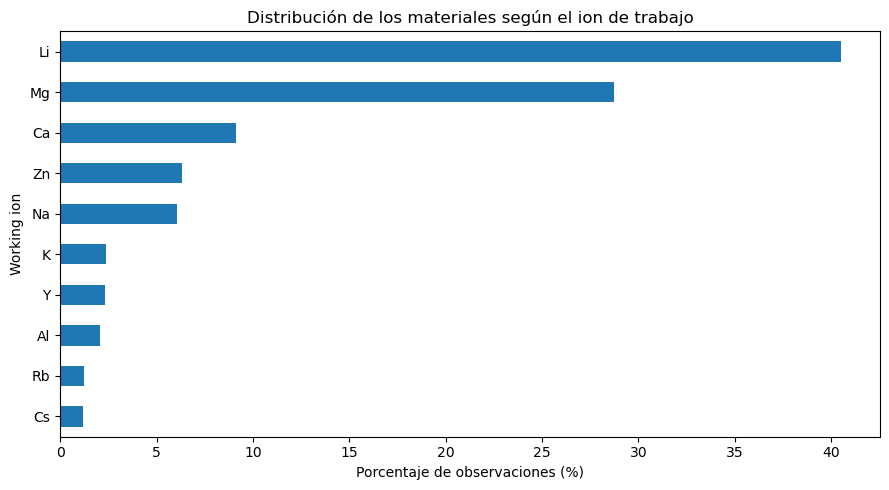

In [54]:
fig, ax = plt.subplots(figsize=(9, 5))

ion_pct.sort_values(ascending=True).plot(
    kind="barh",
    ax=ax
)

ax.set_xlabel("Porcentaje de observaciones (%)")
ax.set_ylabel("Working ion")
ax.set_title("Distribución de los materiales según el ion de trabajo")

plt.tight_layout()

plt.show()

### 5. Fórmulas vacías

In [55]:
df_clean["battery_formula"].isna().sum()
df_clean["framework_formula"].isna().sum()

np.int64(0)

In [56]:
(df_clean["battery_formula"].astype(str).str.strip() == "").sum()

np.int64(0)

In [57]:
(df_clean["framework_formula"].astype(str).str.strip() == "").sum()

np.int64(0)

### 5. Rangos numéricos

In [58]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()

In [59]:
df_clean[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
average_voltage,6847.0,2.521887,1.770710,-7.754751,1.307460,2.732292,3.768411,33.065771
capacity_grav,6847.0,152.910364,175.503892,3.723542,79.505407,118.122620,169.890526,2557.626877
capacity_vol,6847.0,589.297900,550.194853,18.845006,313.222963,477.450426,673.742017,7619.191251
energy_grav,6847.0,346.687108,332.771487,-924.215293,117.309278,292.866986,515.863868,4782.906878
energy_vol,6847.0,1324.173345,1222.695181,-3521.815468,474.876278,1109.517543,1944.929704,13932.216223
max_delta_volume,6847.0,0.400757,5.675405,0.000016,0.021815,0.053264,0.109144,293.193218
max_voltage_step,6847.0,0.096306,0.393320,0.000000,0.000000,0.000000,0.000000,7.140352
stability_charge,6847.0,0.120506,0.311049,0.000000,0.019721,0.063910,0.119440,6.485674
stability_discharge,6847.0,0.128841,0.262277,0.000000,0.027335,0.068136,0.152747,5.882686
num_steps,6847.0,1.114357,0.386271,1.000000,1.000000,1.000000,1.000000,6.000000


Aqui ya se observan valores extremos en las variables objetivo

In [60]:
ranges = pd.DataFrame({
    "min": df_clean[numeric_cols].min(),
    "p01": df_clean[numeric_cols].quantile(0.01),
    "median": df_clean[numeric_cols].median(),
    "p99": df_clean[numeric_cols].quantile(0.99),
    "max": df_clean[numeric_cols].max()
})

ranges

,min,p01,median,p99,max
average_voltage,-7.754751,-1.441318,2.732292,5.745745,33.065771
capacity_grav,3.723542,18.632958,118.122620,872.952077,2557.626877
capacity_vol,18.845006,80.367640,477.450426,3190.871511,7619.191251
energy_grav,-924.215293,-159.063684,292.866986,1369.513761,4782.906878
energy_vol,-3521.815468,-675.929465,1109.517543,5211.977708,13932.216223
max_delta_volume,0.000016,0.000808,0.053264,6.926739,293.193218
max_voltage_step,0.000000,0.000000,0.000000,2.048905,7.140352
stability_charge,0.000000,0.000000,0.063910,1.189979,6.485674
stability_discharge,0.000000,0.000000,0.068136,0.913647,5.882686
num_steps,1.000000,1.000000,1.000000,3.000000,6.000000


### 6. Valores negativos

In [61]:
negative_counts = pd.Series({
    col: (df[col] < 0).sum()
    for col in numeric_cols
})

negative_counts

average_voltage        641
capacity_grav            0
capacity_vol             0
energy_grav            641
energy_vol             641
max_delta_volume         0
max_voltage_step         0
stability_charge         0
stability_discharge      0
num_steps                0
dtype: int64

In [62]:
mask_voltage_neg = df_clean["average_voltage"] < 0
mask_energy_grav_neg = df_clean["energy_grav"] < 0
mask_energy_vol_neg = df_clean["energy_vol"] < 0

print("Voltaje negativo:", mask_voltage_neg.sum())
print("Energy grav negativa:", mask_energy_grav_neg.sum())
print("Energy vol negativa:", mask_energy_vol_neg.sum())

print(
    "Coinciden voltage y energy_grav:",
    (mask_voltage_neg == mask_energy_grav_neg).all()
)

print(
    "Coinciden voltage y energy_vol:",
    (mask_voltage_neg == mask_energy_vol_neg).all()
)

Voltaje negativo: 641
Energy grav negativa: 641
Energy vol negativa: 641
Coinciden voltage y energy_grav: True
Coinciden voltage y energy_vol: True


In [63]:
df_negativos = df_clean.loc[
    df_clean["average_voltage"] < 0,
    [
        "battery_formula",
        "working_ion",
        "average_voltage",
        "capacity_grav",
        "energy_grav",
        "max_delta_volume",
        "stability_charge",
        "stability_discharge"
    ]
]

df_negativos.head(20)

,battery_formula,working_ion,average_voltage,capacity_grav,energy_grav,max_delta_volume,stability_charge,stability_discharge
0,Cs0-3Ac,Cs,-0.707763,128.499827,-90.947418,6.270133,0.020409,0.535925
1,Ca0-3Ac,Ca,-0.034773,463.113885,-16.103762,2.709372,0.020409,0.057262
3,Na0-3Ag,Na,-0.008959,454.679804,-4.073349,5.098846,0.003609,0.045182
7,Mg2-3Ag,Mg,-0.005601,296.504113,-1.660705,0.356026,0.014752,0.021152
23,Mg0-0.5Co3AgP3(HO6)2,Mg,-0.765255,45.912582,-35.134850,0.045014,0.006843,0.179017
32,Mg0-0.5Cs2NbAgS4,Mg,-0.611714,44.154152,-27.009706,0.010121,0.000000,0.146160
33,Mg0-0.5Cs2Ti(AgS2)2,Mg,-0.408498,40.012554,-16.345032,0.011266,0.000000,0.150747
52,Mg0-0.5K2NbAgS4,Mg,-0.409442,63.906829,-26.166113,0.021075,0.000000,0.186696
54,Mg0-0.5LaTiAgO4,Mg,-0.073054,72.281953,-5.280488,0.137728,0.090224,0.436560
60,Mg0-0.5Ag2MoO4,Mg,-0.351005,69.106885,-24.256869,0.154261,0.001024,0.426564


In [64]:
negativos_por_ion = (
    df_clean
    .assign(voltage_negative=df_clean["average_voltage"] < 0)
    .groupby("working_ion")
    .agg(
        n_total=("battery_formula", "size"),
        n_negativos=("voltage_negative", "sum"),
        porcentaje_negativos=("voltage_negative", "mean")
    )
)

negativos_por_ion["porcentaje_negativos"] *= 100

negativos_por_ion.sort_values(
    "porcentaje_negativos",
    ascending=False
)

,n_total,n_negativos,porcentaje_negativos
working_ion,,,
Mg,1968,413,20.985772
Zn,434,65,14.976959
Al,143,15,10.489510
Rb,83,8,9.638554
Cs,81,5,6.172840
K,164,10,6.097561
Ca,625,38,6.080000
Na,416,13,3.125000
Li,2774,72,2.595530


In [65]:
df_clean["energy_estimada"] = (
    df_clean["average_voltage"]
    * df_clean["capacity_grav"]
)

comparison = df_clean[
    [
        "average_voltage",
        "capacity_grav",
        "energy_grav",
        "energy_estimada"
    ]
].copy()

comparison["diferencia"] = (
    comparison["energy_grav"]
    - comparison["energy_estimada"]
)

comparison.head(20)

,average_voltage,capacity_grav,energy_grav,energy_estimada,diferencia
0,-0.707763,128.499827,-90.947418,-90.947418,-9.947598e-14
1,-0.034773,463.113885,-16.103762,-16.103762,0.000000e+00
2,2.147050,64.606066,138.712466,138.712466,0.000000e+00
3,-0.008959,454.679804,-4.073349,-4.073349,-2.664535e-13
4,0.210565,624.785871,131.558310,131.558310,5.968559e-13
5,0.013563,2069.771606,28.072799,28.072799,2.700062e-13
6,0.042793,1168.364239,49.997250,49.997250,7.105427e-15
7,-0.005601,296.504113,-1.660705,-1.660705,-1.083578e-13
8,0.109779,154.071524,16.913873,16.913873,3.197442e-14
9,2.364645,156.386393,369.798324,369.798324,5.684342e-14


In [66]:
comparison[
    ["energy_grav", "energy_estimada"]
].corr()

,energy_grav,energy_estimada
energy_grav,1.0,1.0
energy_estimada,1.0,1.0


Como la correlación es 1, quiere decir que las energías negativas son consecuencia directa del signo de average_voltage.

### 7. Outliers

In [67]:
outlier_report = []

for col in numeric_cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (df_clean[col] < lower) | (df_clean[col] > upper)

    outlier_report.append({
        "variable": col,
        "Q1": q1,
        "Q3": q3,
        "limite_inferior": lower,
        "limite_superior": upper,
        "n_outliers": mask.sum(),
        "porcentaje_outliers": mask.mean() * 100
    })

outlier_report = pd.DataFrame(outlier_report)

outlier_report.sort_values(
    "porcentaje_outliers",
    ascending=False
).round(3)

,variable,Q1,Q3,limite_inferior,limite_superior,n_outliers,porcentaje_outliers
6,max_voltage_step,0.000,0.000,0.000,0.000,659,9.625
9,num_steps,1.000,1.000,1.000,1.000,659,9.625
7,stability_charge,0.020,0.119,-0.130,0.269,563,8.223
5,max_delta_volume,0.022,0.109,-0.109,0.240,522,7.624
8,stability_discharge,0.027,0.153,-0.161,0.341,438,6.397
2,capacity_vol,313.223,673.742,-227.556,1214.521,431,6.295
1,capacity_grav,79.505,169.891,-56.072,305.468,389,5.681
4,energy_vol,474.876,1944.930,-1730.204,4150.010,213,3.111
3,energy_grav,117.309,515.864,-480.523,1113.696,174,2.541
0,average_voltage,1.307,3.768,-2.384,7.460,24,0.351


In [68]:
cols_revision = [
    "max_voltage_step",
    "num_steps",
    "stability_charge",
    "max_delta_volume",
    "stability_discharge",
    "capacity_vol",
    "capacity_grav",
    "energy_vol",
    "energy_grav",
    "average_voltage"
]

df_clean[cols_revision].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T.round(3)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
max_voltage_step,6847.0,0.096,0.393,0.000,0.000,0.000,0.000,0.000,0.000,0.760,2.049,7.140
num_steps,6847.0,1.114,0.386,1.000,1.000,1.000,1.000,1.000,1.000,2.000,3.000,6.000
stability_charge,6847.0,0.121,0.311,0.000,0.000,0.000,0.020,0.064,0.119,0.341,1.190,6.486
max_delta_volume,6847.0,0.401,5.675,0.000,0.001,0.004,0.022,0.053,0.109,0.344,6.927,293.193
stability_discharge,6847.0,0.129,0.262,0.000,0.000,0.000,0.027,0.068,0.153,0.390,0.914,5.883
capacity_vol,6847.0,589.298,550.195,18.845,80.368,158.438,313.223,477.450,673.742,1297.619,3190.872,7619.191
capacity_grav,6847.0,152.910,175.504,3.724,18.633,37.838,79.505,118.123,169.891,324.617,872.952,2557.627
energy_vol,6847.0,1324.173,1222.695,-3521.815,-675.929,-140.094,474.876,1109.518,1944.930,3574.907,5211.978,13932.216
energy_grav,6847.0,346.687,332.771,-924.215,-159.064,-32.531,117.309,292.867,515.864,927.690,1369.514,4782.907
average_voltage,6847.0,2.522,1.771,-7.755,-1.441,-0.350,1.307,2.732,3.768,4.958,5.746,33.066


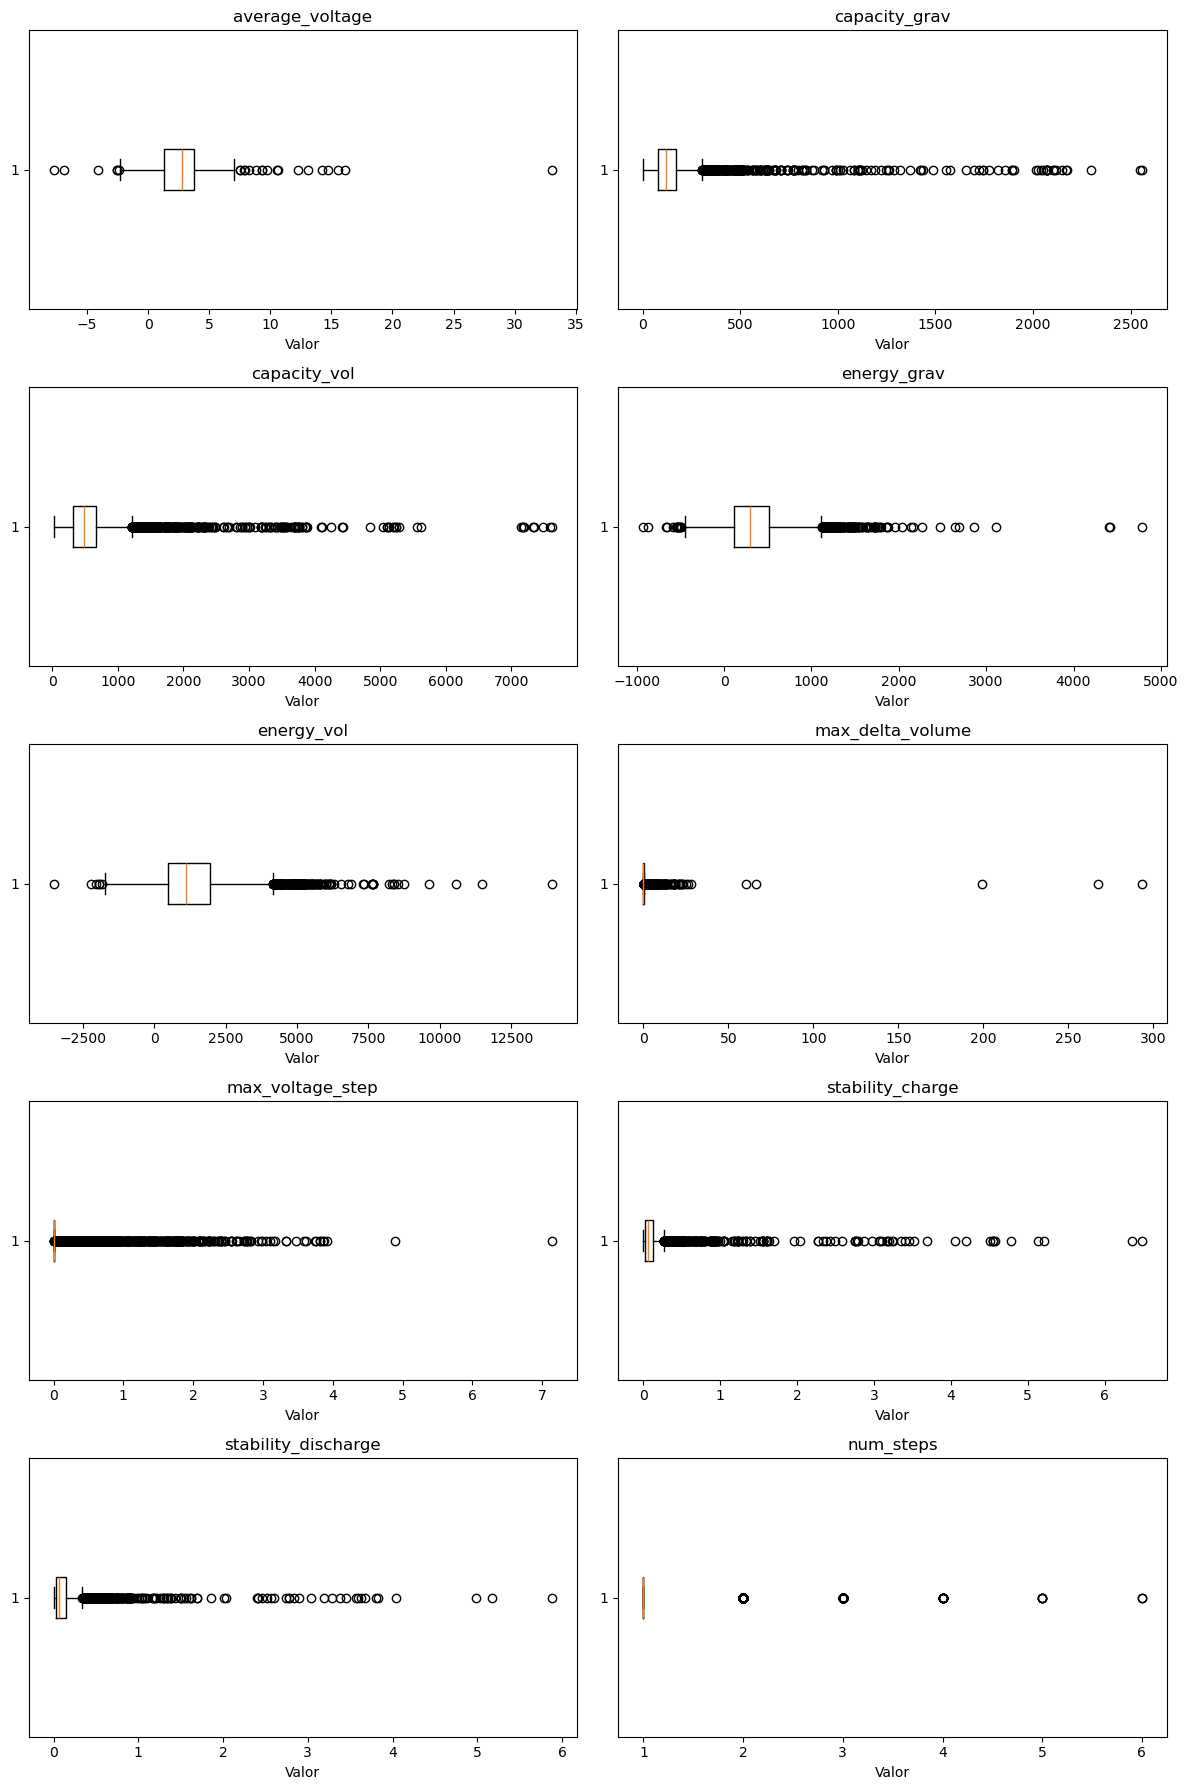

In [69]:
numeric_cols = [
    "average_voltage",
    "capacity_grav",
    "capacity_vol",
    "energy_grav",
    "energy_vol",
    "max_delta_volume",
    "max_voltage_step",
    "stability_charge",
    "stability_discharge",
    "num_steps"
]

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(12, 18)
)

axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    ax.boxplot(df_clean[col].dropna(), vert=False)
    ax.set_title(col)
    ax.set_xlabel("Valor")

plt.tight_layout()
plt.show()

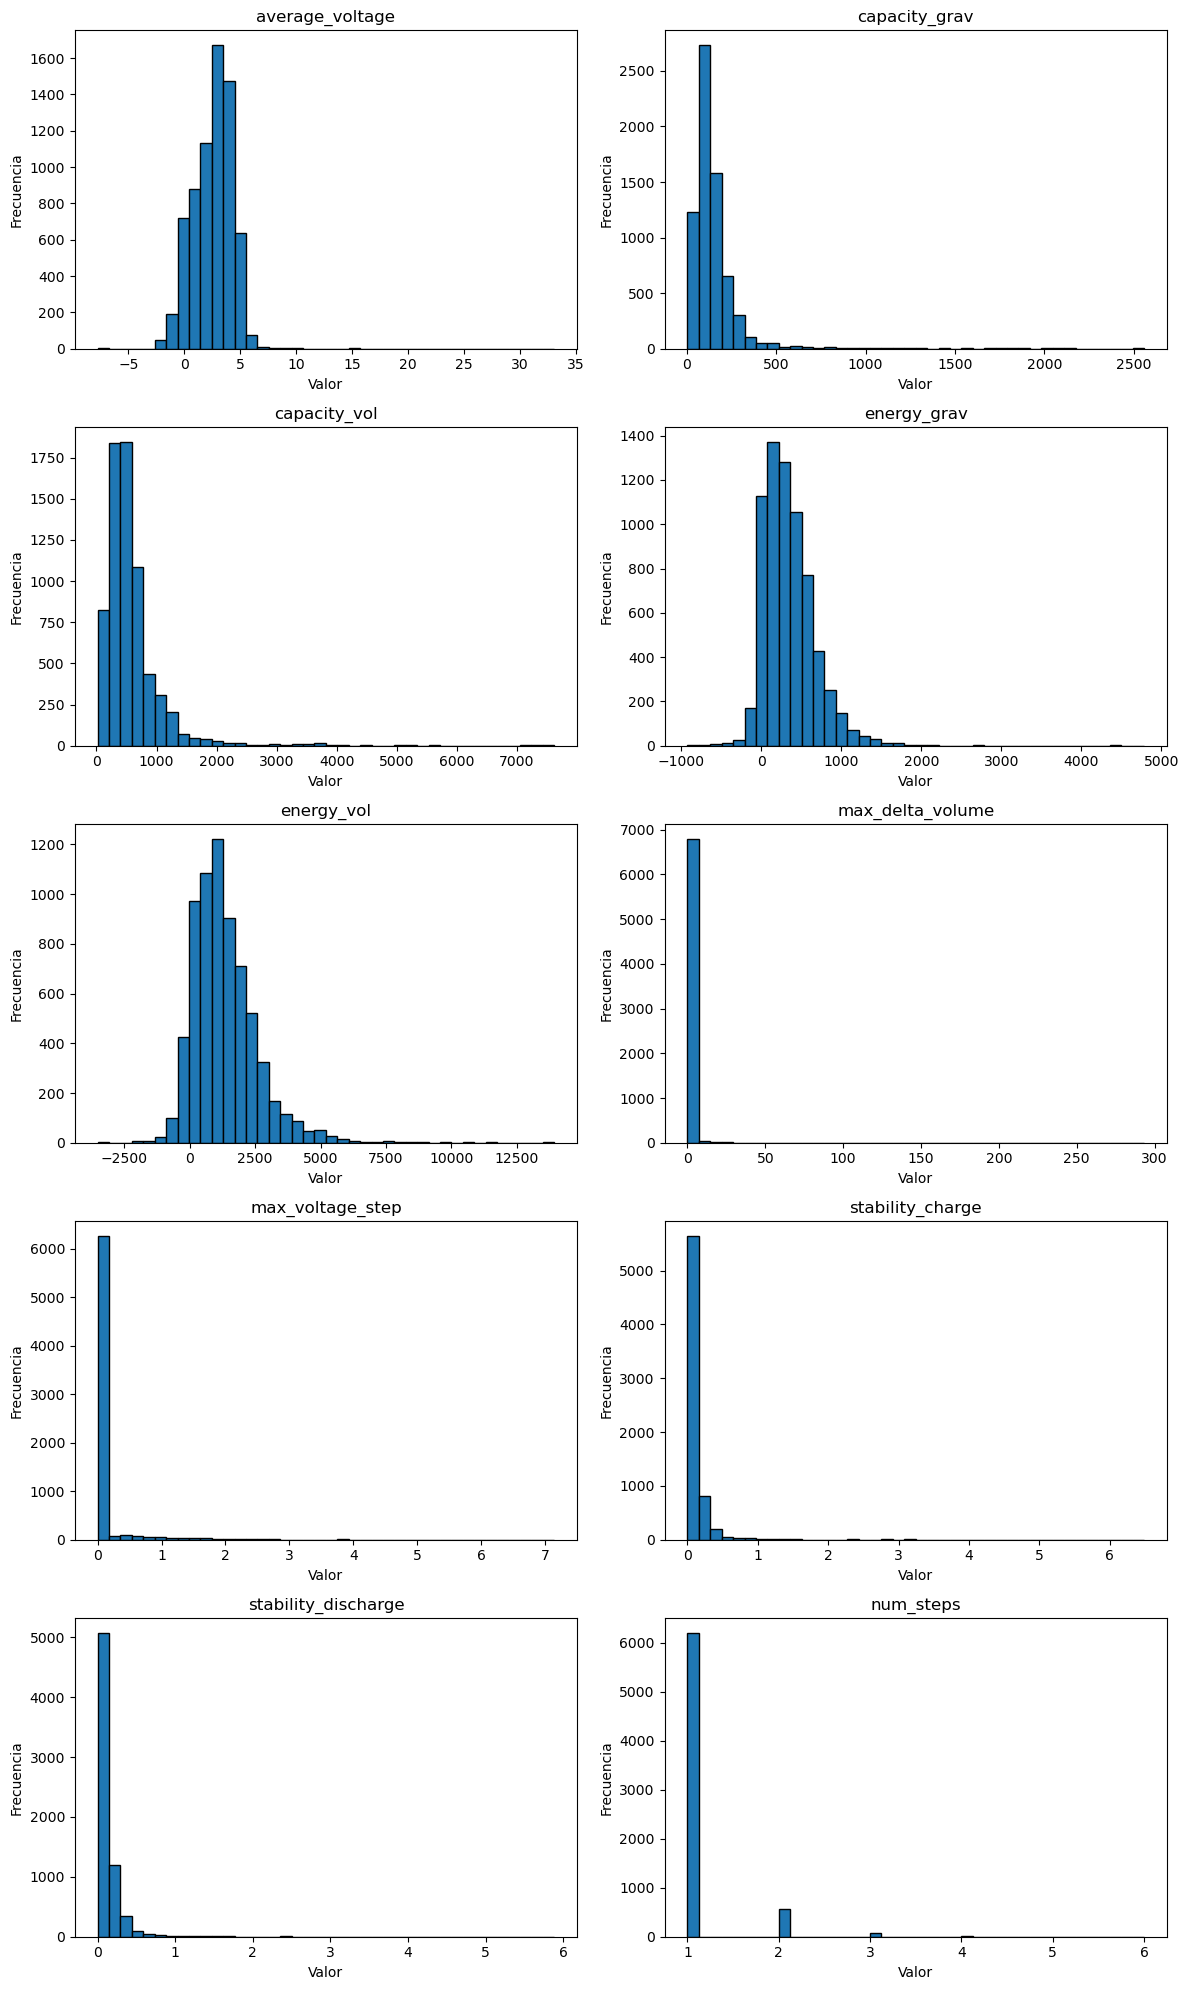

In [70]:
n_cols = 2
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(12, 4 * n_rows)
)

axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    ax.hist(
        df_clean[col].dropna(),
        bins=40,
        edgecolor="black"
    )
    
    ax.set_title(col)
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frecuencia")

# Eliminar ejes sobrantes
for ax in axes[len(numeric_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

In [71]:
numeric_cols = [
    c for c in numeric_cols
    if c in df.columns
]

corr = df[numeric_cols].corr()

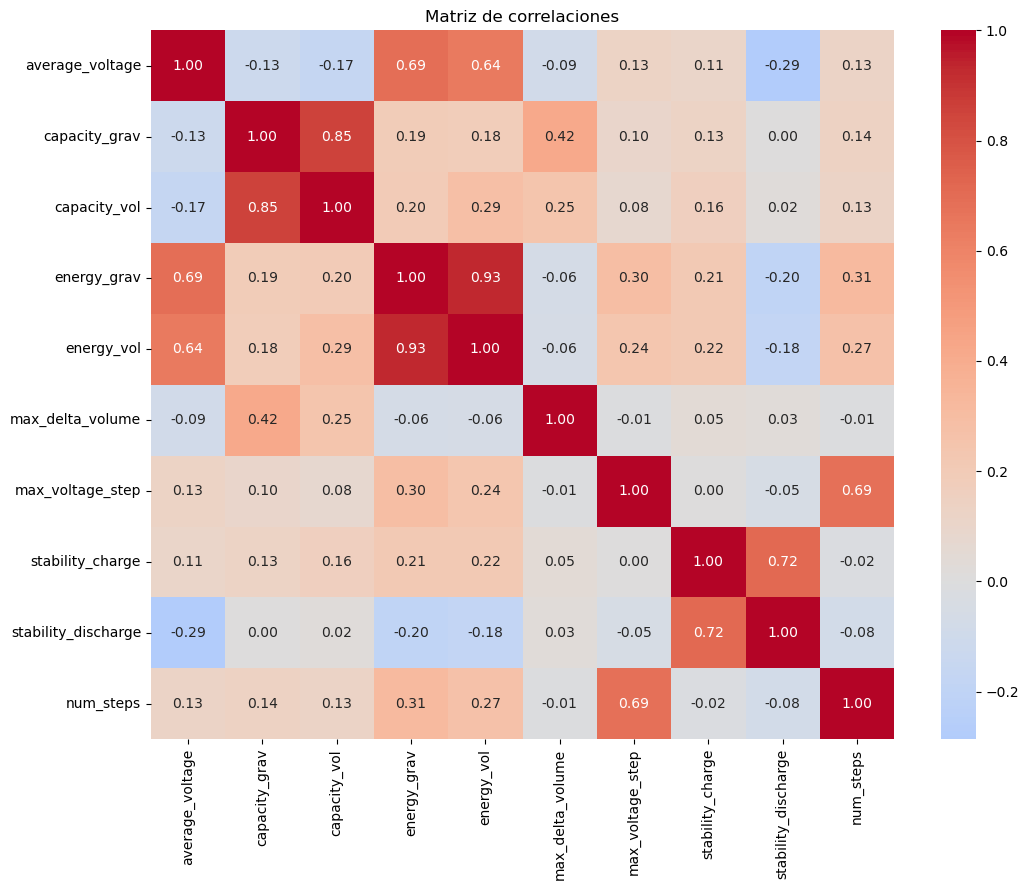

In [72]:
plt.figure(figsize=(11, 9))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlaciones")

plt.tight_layout()


plt.show()

In [73]:
df_clean.to_csv(
    r"datos_baterias_mp\baterias_clean.csv",
    index=False
)